In [1]:
"""
    This is a Deep Learning solution for Kaggle titanic Competition
    This script uses a neural network to predict passenger survival on the Titanic
"""

# ============================================================================
# STEP 1: Set environment variables BEFORE importing TensorFlow
# ============================================================================
import os
import warnings

# Suppress TensorFlow warnings and errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress all TF logging (0=all, 1=info, 2=warning, 3=error)
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Disable oneDNN custom operations
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # Optional: Force CPU if GPU causes issues

# Suppress Python warnings
warnings.filterwarnings('ignore')

# ============================================================================
# STEP 2: Import all libraries AFTER setting environment variables
# ============================================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Import TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

E0000 00:00:1765939919.358908    4754 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765939919.367188    4754 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
###   SETTING RANDOM SEEDS FOR REPRODUCIBILITY

#Sets global seed for numpy's random number generator
np.random.seed(42)
#Sets global seed for tensorflow's random number generator
tf.random.set_seed(42)

# 1. Load Data

In [3]:
### LOAD DATA

train_df = pd.read_csv('/kaggle/input/titanic/train.csv')
test_df = pd.read_csv('/kaggle/input/titanic/test.csv')

test_passenger_ids = test_df['PassengerId'].copy()

In [4]:
print(f"Traning data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print("\nFirst few rows of training data:")
print(train_df.head())

Traning data shape: (891, 12)
Test data shape: (418, 11)

First few rows of training data:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0         

# 2. Feature enginering and preprocessing

In [5]:
def preprocess_data(df, is_train=True):
    """
    Clean and engineer features from raw Titanic data
    
    Args:
        df: DataFrame containing Titanic passenger data
        is_train: Boolean indicating if this is training data (has 'Survived' column)
    
    Returns:
        Processed DataFrame ready for neural network
    """
    
    # Create a copy to avoid modifying original data
    data = df.copy()
    
    # ========================================================================
    # HANDLE MISSING VALUES
    # ========================================================================
    
    # FIX: Use direct assignment instead of inplace=True
    # This avoids the FutureWarning about chained assignment
    
    # Age: Fill missing ages with the median age
    # Median is better than mean because it's not affected by extreme values
    data['Age'] = data['Age'].fillna(data['Age'].median())
    
    # Fare: Fill missing fares with median fare
    data['Fare'] = data['Fare'].fillna(data['Fare'].median())
    
    # Embarked: Fill missing embarkation port with the most common one (mode)
    data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
    
    # Cabin: Most cabins are missing, so we create a binary feature
    # 1 if cabin info exists, 0 if missing (indicates wealth/importance)
    data['HasCabin'] = data['Cabin'].notna().astype(int)
    
    # ========================================================================
    # CREATE NEW FEATURES (Feature Engineering)
    # ========================================================================
    
    # Family Size: Total number of family members aboard
    # This combines siblings/spouses (SibSp) and parents/children (Parch)
    # +1 to include the passenger themselves
    data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
    
    # IsAlone: Binary feature indicating if passenger traveled alone
    # Solo travelers may have different survival rates than those with family
    data['IsAlone'] = (data['FamilySize'] == 1).astype(int)
    
    # Title: Extract title from name (Mr, Mrs, Miss, Master, etc.)
    # Titles indicate social status, age group, and gender
    data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    
    # Group rare titles together to reduce noise
    # This prevents overfitting on uncommon titles
    rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 
                   'Rev', 'Sir', 'Jonkheer', 'Dona']
    data['Title'] = data['Title'].replace(rare_titles, 'Rare')
    data['Title'] = data['Title'].replace('Mlle', 'Miss')
    data['Title'] = data['Title'].replace('Ms', 'Miss')
    data['Title'] = data['Title'].replace('Mme', 'Mrs')
    
    # Age Groups: Categorize ages into bins
    # Children, teenagers, adults, and elderly may have different survival rates
    data['AgeGroup'] = pd.cut(data['Age'], bins=[0, 12, 18, 35, 60, 100], 
                               labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])
    
    # Fare per person: Divide fare by family size
    # This normalizes fare by how many people shared the ticket cost
    data['FarePerPerson'] = data['Fare'] / data['FamilySize']
    
    # ========================================================================
    # ENCODE CATEGORICAL VARIABLES
    # ========================================================================
    
    # Convert Sex to binary: male=1, female=0
    data['Sex'] = data['Sex'].map({'male': 1, 'female': 0})
    
    # One-hot encode Embarked (port of embarkation: C=Cherbourg, Q=Queenstown, S=Southampton)
    # Creates separate binary columns for each port
    embarked_dummies = pd.get_dummies(data['Embarked'], prefix='Embarked')
    data = pd.concat([data, embarked_dummies], axis=1)
    
    # One-hot encode Title
    title_dummies = pd.get_dummies(data['Title'], prefix='Title')
    data = pd.concat([data, title_dummies], axis=1)
    
    # One-hot encode AgeGroup
    agegroup_dummies = pd.get_dummies(data['AgeGroup'], prefix='AgeGroup')
    data = pd.concat([data, agegroup_dummies], axis=1)
    
    # ========================================================================
    # SELECT FINAL FEATURES FOR MODEL
    # ========================================================================
    
    # Drop columns that are not useful for prediction or have been transformed
    columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'Embarked', 
                       'Title', 'AgeGroup']
    
    # If this is training data, keep 'Survived' column
    if is_train:
        columns_to_drop = [col for col in columns_to_drop if col in data.columns]
    else:
        columns_to_drop = [col for col in columns_to_drop if col in data.columns]
    
    data = data.drop(columns=columns_to_drop)
    
    return data

In [6]:
#Apply preprocessing to both training and test data
print("\nPreprocessing training data...")
train_processed = preprocess_data(train_df, is_train=True)

print("\nPreprocessing test data...")
test_processed = preprocess_data(test_df, is_train=False)


Preprocessing training data...

Preprocessing test data...


# 3. Prepare Data for neural network

In [7]:
#Separate feature (X) rom target variable(u)
# X contains all passenger informatin, y contains survival outcome(0 or 1)
X = train_processed.drop('Survived', axis=1)
y=train_processed['Survived']

#Ensure test data has the same features as training data
# this handels cases where one0hot encoding might create different columns
X_test = test_processed.reindex(columns=X.columns, fill_value=0)

print(f"\nFeature shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

#Split training data intio training and validataion sets
#80% training data, 20% data for validation
# Validatino set helps us monitor overfitting during training
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify=y
)


Feature shape: (891, 23)
Target shape: (891,)

Feature columns: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'FamilySize', 'IsAlone', 'FarePerPerson', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeGroup_Child', 'AgeGroup_Teen', 'AgeGroup_Adult', 'AgeGroup_Middle', 'AgeGroup_Senior']


# 4. Feature scaling

In [8]:
# Standardize features by removing mean and scaling to unit variance
# Neural Networks perform better when feaures are on similar scales
# Formula: z = (x-mean)/standard_deviation
scaler = StandardScaler()

#Fit scaler on training data only (to prevemt data leakage)
X_train_scaled = scaler.fit_transform(X_train)

#Transform validatino and test data using the same scaler
X_val_scaled = scaler.fit_transform(X_val)
X_test_scaled = scaler.fit_transform(X_test)

#Transform validation and test data using the same scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set size: {X_train_scaled.shape}")
print(f"\Validation set size: {X_val_scaled.shape}")
print(f"\Test set size: {X_test_scaled.shape}")



Training set size: (712, 23)
\Validation set size: (179, 23)
\Test set size: (418, 23)


# 5. Building neural network model

In [9]:
def create_model(input_dim):
    """
    Build a deep neural network for binary classification
    
    Args:
        input_dim: Number of input features
    
    Returns:
        Compiled Keras model
    """
    
    # Initialize sequential model (layers stacked one after another)
    model = keras.Sequential([
        
        # Input layer: Explicitly define the input shape
        layers.Input(shape=(input_dim,)),
        
        # First hidden layer: 128 neurons
        # ReLU activation: outputs max(0, x) - introduces non-linearity
        layers.Dense(128, activation='relu', name='hidden_layer_1'),
        
        # Dropout: Randomly sets 30% of inputs to 0 during training
        # This prevents overfitting by forcing network to not rely on specific neurons
        layers.Dropout(0.3, name='dropout_1'),
        
        # Batch Normalization: Normalizes inputs to this layer
        # Helps with faster training and better generalization
        layers.BatchNormalization(name='batch_norm_1'),
        
        # Second hidden layer: 64 neurons
        layers.Dense(64, activation='relu', name='hidden_layer_2'),
        layers.Dropout(0.3, name='dropout_2'),
        layers.BatchNormalization(name='batch_norm_2'),
        
        # Third hidden layer: 32 neurons
        layers.Dense(32, activation='relu', name='hidden_layer_3'),
        layers.Dropout(0.2, name='dropout_3'),
        
        # Output layer: 1 neuron with sigmoid activation
        # Sigmoid squashes output to range [0, 1] representing probability of survival
        # Values closer to 1 = higher chance of survival
        layers.Dense(1, activation='sigmoid', name='output_layer')
    ])
    
    # Compile model with:
    # - Adam optimizer: Adaptive learning rate optimization algorithm
    # - Binary crossentropy loss: Standard loss function for binary classification
    # - Accuracy metric: Percentage of correct predictions
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [10]:
# Create the model
input_dimension = X_train_scaled.shape[1]
model = create_model(input_dimension)

# Display model architecture
print("\nModel Architecture:")
#model.summary()


Model Architecture:


# 6. Define callbacks for training

In [11]:
# EarlyStopping: Stop training if validation loss doesn't improve
# Prevents overfitting and saves time
# Patience=15 means wait 15 epochs before stopping
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',          # Watch validation loss
    patience=15,                 # Wait 15 epochs without improvement
    restore_best_weights=True,   # Restore weights from best epoch
    verbose=1
)

# ReduceLROnPlateau: Reduce learning rate when learning plateaus
# Helps fine-tune the model when it stops improving
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',          # Watch validation loss
    factor=0.5,                  # Multiply learning rate by 0.5
    patience=5,                  # Wait 5 epochs without improvement
    min_lr=0.00001,              # Don't go below this learning rate
    verbose=1
)

# 7. Train the model

In [12]:
print("\nTraining the model...")
print("=" * 70)

# Train the neural network
history = model.fit(
    X_train_scaled,              # Training features
    y_train,                     # Training labels
    validation_data=(X_val_scaled, y_val),  # Validation data for monitoring
    epochs=100,                  # Maximum number of training iterations
    batch_size=32,               # Number of samples per gradient update
    callbacks=[early_stop, reduce_lr],  # Use callbacks defined above
    verbose=1                    # Print progress
)

print("=" * 70)
print("Training completed!")


Training the model...
Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5169 - loss: 0.8065 - val_accuracy: 0.8101 - val_loss: 0.5781 - learning_rate: 0.0010
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7710 - loss: 0.5238 - val_accuracy: 0.8045 - val_loss: 0.5365 - learning_rate: 0.0010
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7795 - loss: 0.4916 - val_accuracy: 0.8156 - val_loss: 0.5046 - learning_rate: 0.0010
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7486 - loss: 0.5211 - val_accuracy: 0.8324 - val_loss: 0.4823 - learning_rate: 0.0010
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7867 - loss: 0.4961 - val_accuracy: 0.8324 - val_loss: 0.4721 - learning_rate: 0.0010
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7870 - loss: 0.4649 - val_accuracy: 0.8324 - val_loss: 0.4613 - learning_rate: 0.0010
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7837 

# 8. Evaluate the model performance

In [13]:
# Evaluate on validation set
val_loss, val_accuracy = model.evaluate(X_val_scaled, y_val, verbose=0)
print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")


Validation Loss: 0.4351
Validation Accuracy: 0.8324 (83.24%)


# 9. Visualize training history


Training history plot saved!


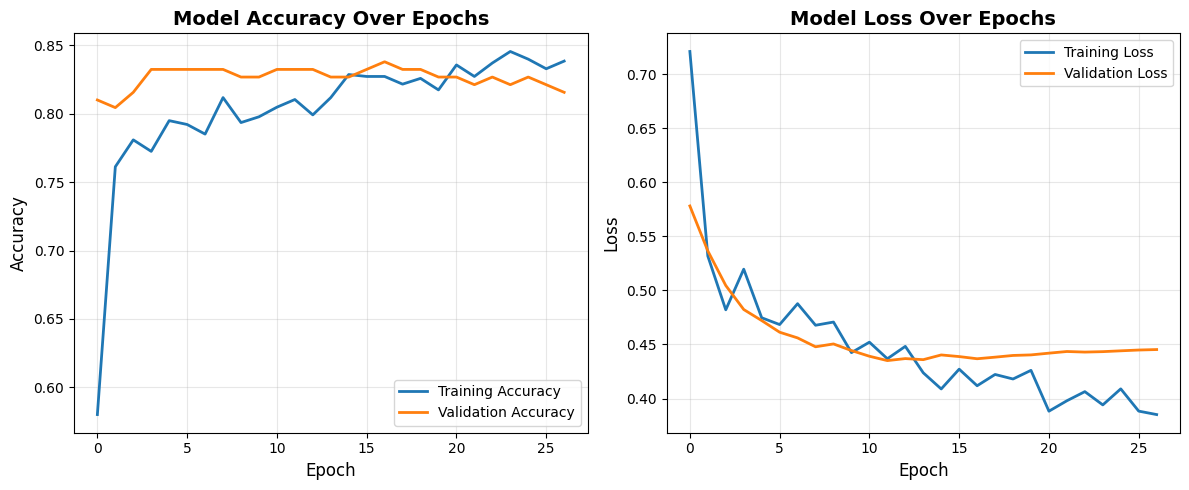

In [14]:
# Plot training and validation accuracy over epochs
plt.figure(figsize=(12, 5))

# Subplot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Subplot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
print("\nTraining history plot saved!")
plt.show()

# 10. Make predictions on test data

In [15]:
predictions_proba = model.predict(X_test_scaled, verbose=0)

# Convert probabilities to binary predictions (0 or 1)
# If probability >= 0.5, predict survival (1), else predict death (0)
predictions = (predictions_proba > 0.5).astype(int).flatten()

print(f"\nPredictions shape: {predictions.shape}")
print(f"Number of predicted survivors: {predictions.sum()}")
print(f"Number of predicted deaths: {len(predictions) - predictions.sum()}")


Predictions shape: (418,)
Number of predicted survivors: 151
Number of predicted deaths: 267


# 11. Create submision file for kaggle

In [16]:
# Create submission DataFrame with PassengerId and Survived columns
submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Survived': predictions
})

# Save to CSV file
# In Kaggle, this will be saved in the working directory
submission.to_csv('submission.csv', index=False)
print("\nSubmission file created: 'submission.csv'")
print("\nFirst few predictions:")
print(submission.head(10))

# Display submission statistics
print("\n" + "=" * 70)
print("SUBMISSION STATISTICS")
print("=" * 70)
print(f"Total predictions: {len(submission)}")
print(f"Predicted survivors: {submission['Survived'].sum()} ({submission['Survived'].sum()/len(submission)*100:.1f}%)")
print(f"Predicted deaths: {len(submission) - submission['Survived'].sum()} ({(len(submission) - submission['Survived'].sum())/len(submission)*100:.1f}%)")



Submission file created: 'submission.csv'

First few predictions:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0

SUBMISSION STATISTICS
Total predictions: 418
Predicted survivors: 151 (36.1%)
Predicted deaths: 267 (63.9%)


In [17]:
import os
print(os.listdir('/kaggle/working'))

['training_history.png', 'feature_importance.png', 'submission1.csv', 'submission.csv', 'decision_tree_visualization.png', '.virtual_documents']


# DECISION TREE APPROACH

 # 2. Data preprocessing

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn import tree

In [19]:
# Load the data
train_data = pd.read_csv('/kaggle/input/titanic/train.csv')
test_data = pd.read_csv('/kaggle/input/titanic/test.csv')

In [20]:
def preprocess_data1(df, is_train=True):
    """Preprocess the data for decision tree model"""
    
    # Create a copy to avoid modifying original data
    data = df.copy()
    
    # Fill missing Age with median
    data['Age'].fillna(data['Age'].median(), inplace=True)
    
    # Fill missing Embarked with mode (most common value)
    data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)
    
    # Fill missing Fare with median
    data['Fare'].fillna(data['Fare'].median(), inplace=True)
    
    # Create new features
    # Family size
    data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
    
    # Is alone
    data['IsAlone'] = (data['FamilySize'] == 1).astype(int)
    
    # Title extraction from Name
    data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    
    # Group rare titles
    title_mapping = {
        'Mr': 'Mr',
        'Miss': 'Miss',
        'Mrs': 'Mrs',
        'Master': 'Master',
        'Dr': 'Rare',
        'Rev': 'Rare',
        'Col': 'Rare',
        'Major': 'Rare',
        'Mlle': 'Miss',
        'Countess': 'Rare',
        'Ms': 'Miss',
        'Lady': 'Rare',
        'Jonkheer': 'Rare',
        'Don': 'Rare',
        'Dona': 'Rare',
        'Mme': 'Mrs',
        'Capt': 'Rare',
        'Sir': 'Rare'
    }
    data['Title'] = data['Title'].map(title_mapping)
    data['Title'].fillna('Rare', inplace=True)
    
    # Age groups
    data['AgeGroup'] = pd.cut(data['Age'], bins=[0, 12, 18, 35, 60, 100], 
                               labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])
    
    # Fare groups
    data['FareGroup'] = pd.qcut(data['Fare'], q=4, labels=['Low', 'Medium', 'High', 'VeryHigh'])
    
    # Convert categorical variables to numerical
    label_encoders = {}
    categorical_columns = ['Sex', 'Embarked', 'Title', 'AgeGroup', 'FareGroup']
    
    for col in categorical_columns:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])
        label_encoders[col] = le
    
    # Select features for the model
    features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 
                'FamilySize', 'IsAlone', 'Title', 'AgeGroup', 'FareGroup']
    
    X = data[features]
    
    if is_train:
        y = data['Survived']
        return X, y, label_encoders
    else:
        return X, label_encoders

In [21]:
# Preprocess training data
X_train_full, y_train_full, label_encoders = preprocess_data1(train_data, is_train=True)

print("\n" + "=" * 70)
print("PREPROCESSED DATA INFO")
print("=" * 70)
print(X_train_full.head())
print("\nFeature columns:", X_train_full.columns.tolist())
print("Data shape:", X_train_full.shape)


PREPROCESSED DATA INFO
   Pclass  Sex   Age     Fare  Embarked  FamilySize  IsAlone  Title  AgeGroup  \
0       3    1  22.0   7.2500         2           2        0      2         0   
1       1    0  38.0  71.2833         0           2        0      3         2   
2       3    0  26.0   7.9250         2           1        1      1         0   
3       1    0  35.0  53.1000         2           2        0      3         0   
4       3    1  35.0   8.0500         2           1        1      2         0   

   FareGroup  
0          1  
1          3  
2          2  
3          3  
4          2  

Feature columns: ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title', 'AgeGroup', 'FareGroup']
Data shape: (891, 10)


In [22]:
### SPlit data for validation
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"\nValidation set size: {X_val.shape[0]}")


Training set size: 712

Validation set size: 179


In [23]:
print("\n" + "=" * 70)
print("BASIC DECISION TREE MODEL")
print("=" * 70)

#Create and train basic decision tree
dt_basic = DecisionTreeClassifier(random_state=42)
dt_basic.fit(X_train, y_train)

# Predictions on validation set
y_pred_basic = dt_basic.predict(X_val)

# Evaluate
accuracy_basic = accuracy_score(y_val, y_pred_basic)
print(f"Validation Accuracy: {accuracy_basic:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_basic))
print("\nClassification Report:")
print(classification_report(y_val, y_pred_basic))


BASIC DECISION TREE MODEL
Validation Accuracy: 0.7542

Confusion Matrix:
[[80 25]
 [19 55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.76      0.78       105
           1       0.69      0.74      0.71        74

    accuracy                           0.75       179
   macro avg       0.75      0.75      0.75       179
weighted avg       0.76      0.75      0.76       179



In [24]:
#optimized decision tree with hyperparameter tuning
print("\n" + "=" * 70)
print("HYPERPARAMETER TUNING")
print("=" * 70)

#Define parameter grid
param_grid = {
    'max_depth': [3,5,7,10, None],
    'min_samples_split': [2,5,10, 20],
    'min_samples_leaf': [1,2,4,8],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None]
}


HYPERPARAMETER TUNING


In [25]:
#Grid search with cross-validation
dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(
    dt, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 480 candidates, totalling 2400 fits

Best parameters: {'criterion': 'gini', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best cross-validation score: 0.8244


In [26]:
#Best model
best_dt = grid_search.best_estimator_

#Predictions on validation set
y_pred_optimized = best_dt.predict(X_val)

In [27]:
#Evaluate
accuracy_optimized = accuracy_score(y_val, y_pred_optimized)
print(f"\nOptimized validatino Accuracy: {accuracy_optimized:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_optimized))
print("\nClassification Report:")
print(classification_report(y_val, y_pred_optimized))


Optimized validatino Accuracy: 0.7989

Confusion Matrix:
[[92 13]
 [23 51]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [28]:
# FEATURE IMPORTANCE
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_dt.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance)

      Feature  Importance
1         Sex    0.605737
0      Pclass    0.209536
2         Age    0.075353
3        Fare    0.061240
5  FamilySize    0.048135
4    Embarked    0.000000
6     IsAlone    0.000000
7       Title    0.000000
8    AgeGroup    0.000000
9   FareGroup    0.000000



Feature importance plot saved as 'feature_importance.png'


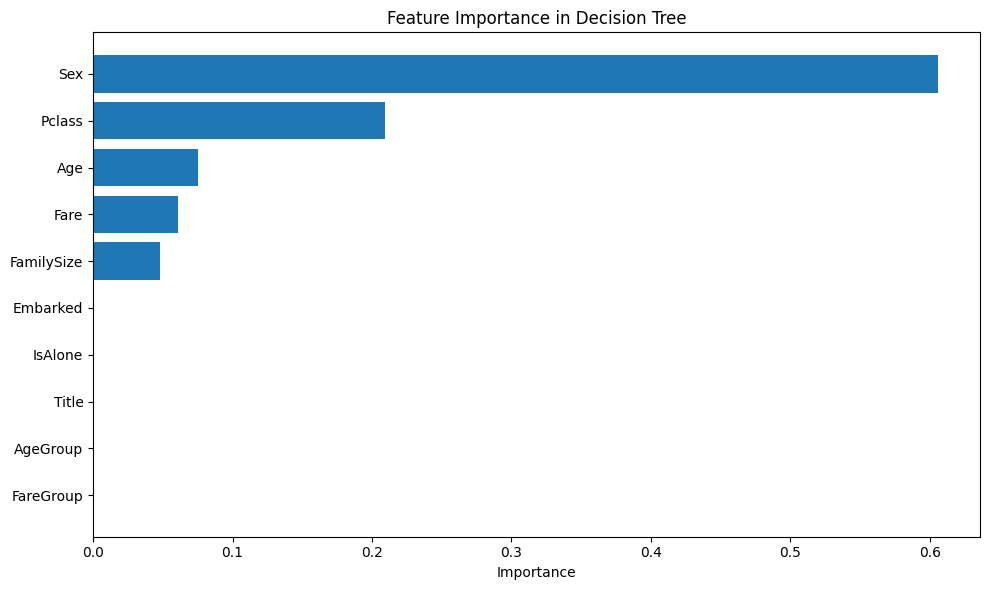

In [29]:
# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance in Decision Tree')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
print("\nFeature importance plot saved as 'feature_importance.png'")


DECISION TREE VISUALIZATION
Decision tree visualization saved as 'decision_tree_visualization.png'


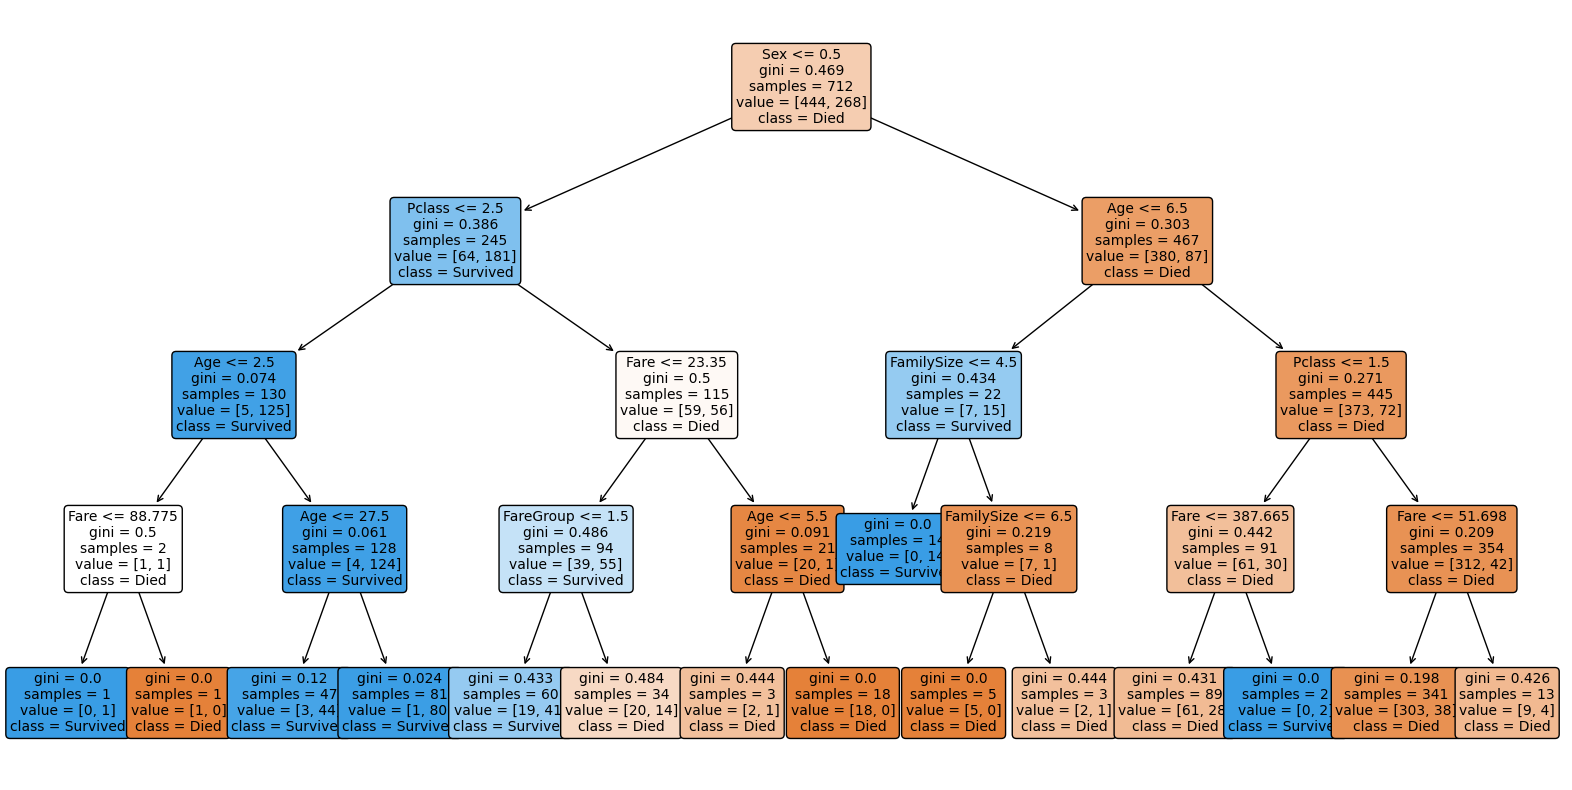

In [30]:
# ============================================================================
# VISUALIZE DECISION TREE
# ============================================================================

print("\n" + "=" * 70)
print("DECISION TREE VISUALIZATION")
print("=" * 70)

# Create a simplified tree for visualization
dt_simple = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_simple.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
tree.plot_tree(dt_simple, 
               feature_names=X_train.columns, 
               class_names=['Died', 'Survived'],
               filled=True, 
               rounded=True,
               fontsize=10)
plt.savefig('decision_tree_visualization.png', dpi=300, bbox_inches='tight')
print("Decision tree visualization saved as 'decision_tree_visualization.png'")

In [31]:
#Training final model on full training data
final_model = DecisionTreeClassifier(**grid_search.best_params_, random_state=42)
final_model.fit(X_train_full, y_train_full)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=2, random_state=42)

In [32]:
#Cross-validation score on full data
cv_scores = cross_val_score(final_model, X_train_full, y_train_full, cv=5)
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Cross-validation scores: [0.81564246 0.81460674 0.8258427  0.78651685 0.82022472]
Mean CV accuracy: 0.8126 (+/- 0.0272)


In [33]:
#making predictions on test data

# Preprocess test data
X_test, _ = preprocess_data1(test_data, is_train=False)

# Make predictions
test_predictions = final_model.predict(X_test)

In [34]:
# Create submission file
submission1 = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': test_predictions
})

submission1.to_csv('submission1.csv', index=False)
print("Submission file created: 'submission1.csv'")
print("\nFirst few predictions:")
print(submission1.head(10))

# Display submission statistics
print("\n" + "=" * 70)
print("SUBMISSION STATISTICS")
print("=" * 70)
print(f"Total predictions: {len(submission1)}")
print(f"Predicted survivors: {submission1['Survived'].sum()} ({submission1['Survived'].sum()/len(submission1)*100:.1f}%)")
print(f"Predicted deaths: {len(submission1) - submission1['Survived'].sum()} ({(len(submission1) - submission1['Survived'].sum())/len(submission1)*100:.1f}%)")


Submission file created: 'submission1.csv'

First few predictions:
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0

SUBMISSION STATISTICS
Total predictions: 418
Predicted survivors: 160 (38.3%)
Predicted deaths: 258 (61.7%)
